In [29]:
import pandas as pd  # For data manipulation
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns  # For nicer looking plots
from statsmodels.tsa.seasonal import seasonal_decompose  # To break down time series into components
from statsmodels.tsa.stattools import adfuller  # To test for stationarity
import warnings
warnings.filterwarnings('ignore')  # Ignore warning messages for cleaner output

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
train = pd.read_csv('//content/drive/MyDrive/data (1)/train.csv')
test =  pd.read_csv('/content/drive/MyDrive/data (1)/test.csv')

In [32]:
train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [33]:
train.shape

(1462, 5)

In [34]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [35]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [36]:
train.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [37]:
train['date'] = pd.to_datetime(train['date'])

In [38]:
train.set_index('date', inplace=True)

In [39]:
train.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [40]:
print(f"\n📅 Date range: from {train.index.min()} to {train.index.max()}")


📅 Date range: from 2013-01-01 00:00:00 to 2017-01-01 00:00:00


In [41]:
len(train)

1462

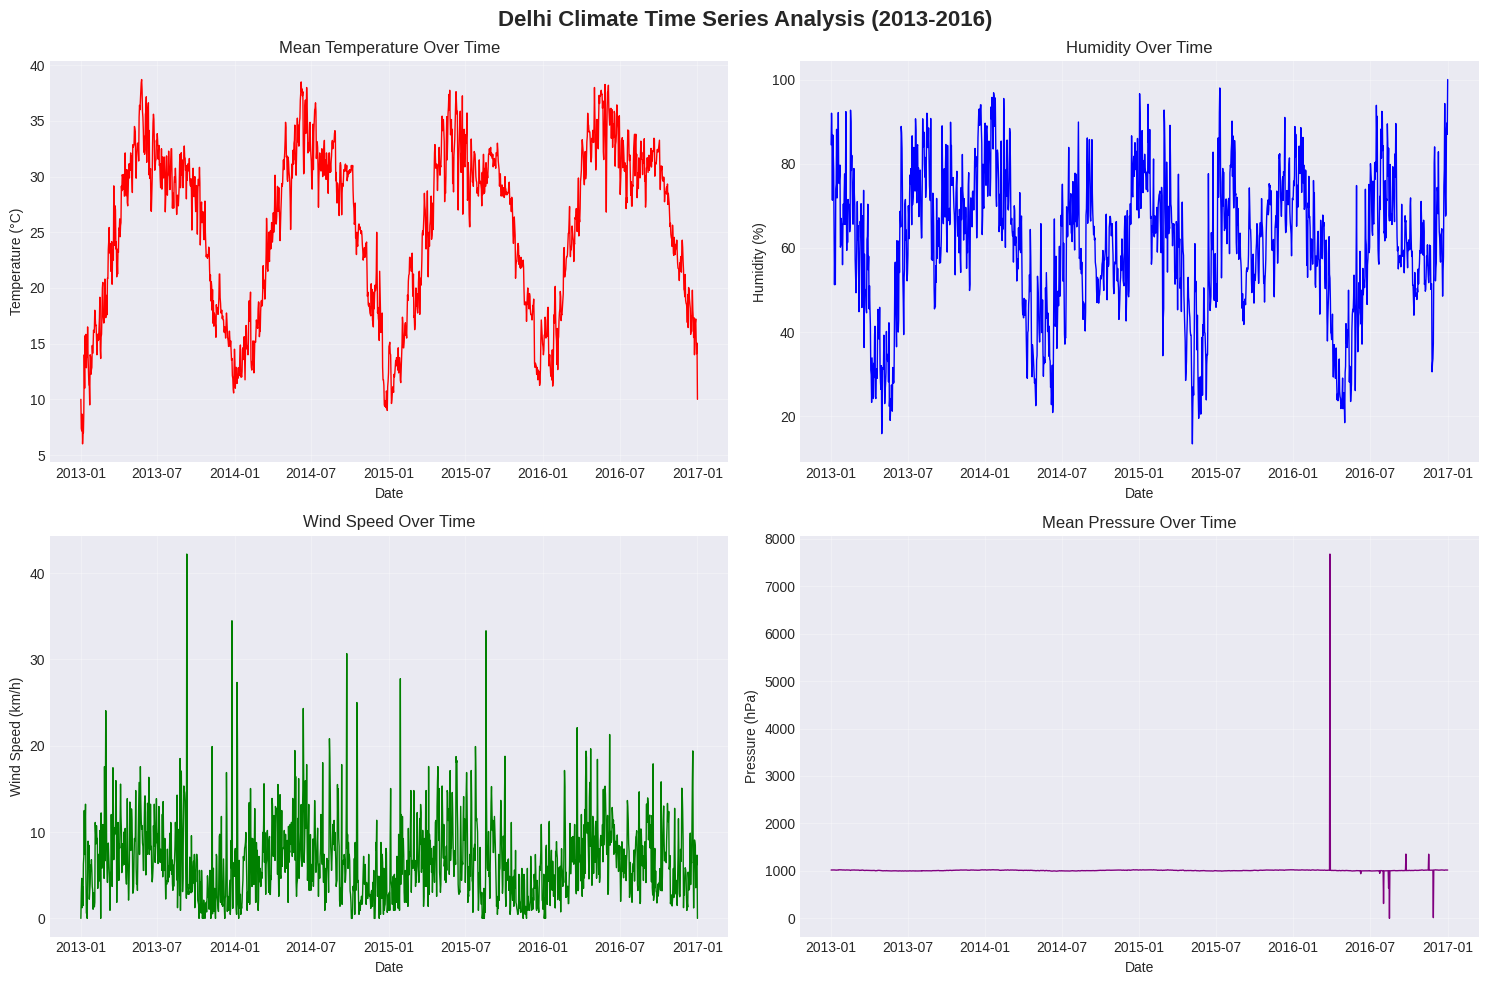

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Delhi Climate Time Series Analysis (2013-2016)', fontsize=16, fontweight='bold')

axes[0, 0].plot(train.index, train['meantemp'], linewidth=1, color='red')
axes[0, 0].set_title('Mean Temperature Over Time', fontsize=12)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Humidity over time
axes[0, 1].plot(train.index, train['humidity'], linewidth=1, color='blue')
axes[0, 1].set_title('Humidity Over Time', fontsize=12)
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Humidity (%)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Wind Speed over time
axes[1, 0].plot(train.index, train['wind_speed'], linewidth=1, color='green')
axes[1, 0].set_title('Wind Speed Over Time', fontsize=12)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Wind Speed (km/h)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Mean Pressure over time
axes[1, 1].plot(train.index, train['meanpressure'], linewidth=1, color='purple')
axes[1, 1].set_title('Mean Pressure Over Time', fontsize=12)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Pressure (hPa)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [43]:
decomposition = seasonal_decompose(train['meantemp'], model='additive', period=365)

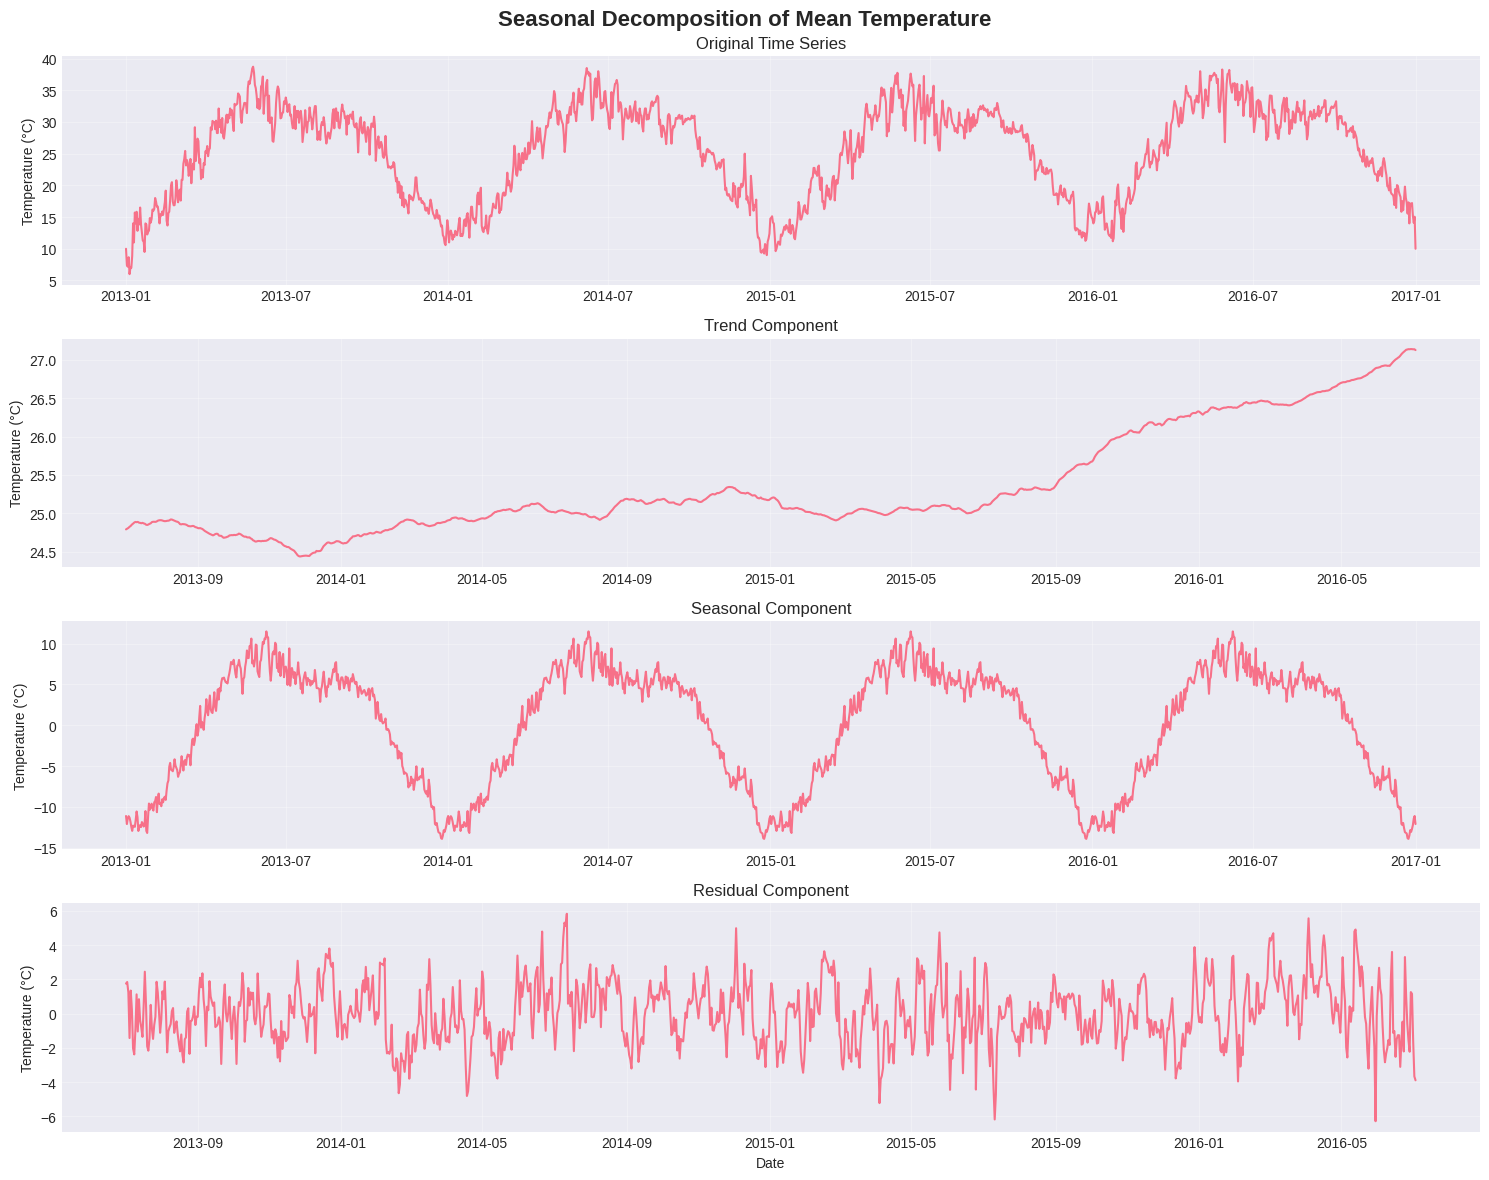

In [44]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('Seasonal Decomposition of Mean Temperature', fontsize=16, fontweight='bold')

# Original data
ax1.plot(train.index, decomposition.observed)
ax1.set_title('Original Time Series')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, alpha=0.3)

# Trend component
ax2.plot(train.index, decomposition.trend)
ax2.set_title('Trend Component')
ax2.set_ylabel('Temperature (°C)')
ax2.grid(True, alpha=0.3)

# Seasonal component
ax3.plot(train.index, decomposition.seasonal)
ax3.set_title('Seasonal Component')
ax3.set_ylabel('Temperature (°C)')
ax3.grid(True, alpha=0.3)

# Residual component
ax4.plot(train.index, decomposition.resid)
ax4.set_title('Residual Component')
ax4.set_xlabel('Date')
ax4.set_ylabel('Temperature (°C)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
def test_stationarity(timeseries, title):
    """
    Perform Augmented Dickey-Fuller test to check stationarity

    Interpretation:
    - If p-value <= 0.05: Series is stationary (reject null hypothesis)
    - If p-value > 0.05: Series is non-stationary (fail to reject null hypothesis)
    """
    print(f"\n📈 Results for: {title}")

    # Perform Dickey-Fuller test
    dftest = adfuller(timeseries.dropna(), autolag='AIC')

    # Create a dataframe to display results
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value',
                                             '#Lags Used', 'Number of Observations'])

    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value

    print(dfoutput)

    # Interpret the results
    if dftest[1] <= 0.05:
        print("✅ Conclusion: The series is STATIONARY (p-value <= 0.05)")
    else:
        print("❌ Conclusion: The series is NON-STATIONARY (p-value > 0.05)")

# Test original temperature series
test_stationarity(train['meantemp'], 'Original Temperature Series')



📈 Results for: Original Temperature Series
Test Statistic              -2.021069
p-value                      0.277412
#Lags Used                  10.000000
Number of Observations    1451.000000
Critical Value (1%)         -3.434865
Critical Value (5%)         -2.863534
Critical Value (10%)        -2.567832
dtype: float64
❌ Conclusion: The series is NON-STATIONARY (p-value > 0.05)


In [46]:
train['temp_diff_1'] = train['meantemp'].diff()


In [47]:
test_stationarity(train['temp_diff_1'], 'Differenced Temperature Series')



📈 Results for: Differenced Temperature Series
Test Statistic           -1.637872e+01
p-value                   2.764863e-29
#Lags Used                9.000000e+00
Number of Observations    1.451000e+03
Critical Value (1%)      -3.434865e+00
Critical Value (5%)      -2.863534e+00
Critical Value (10%)     -2.567832e+00
dtype: float64
✅ Conclusion: The series is STATIONARY (p-value <= 0.05)


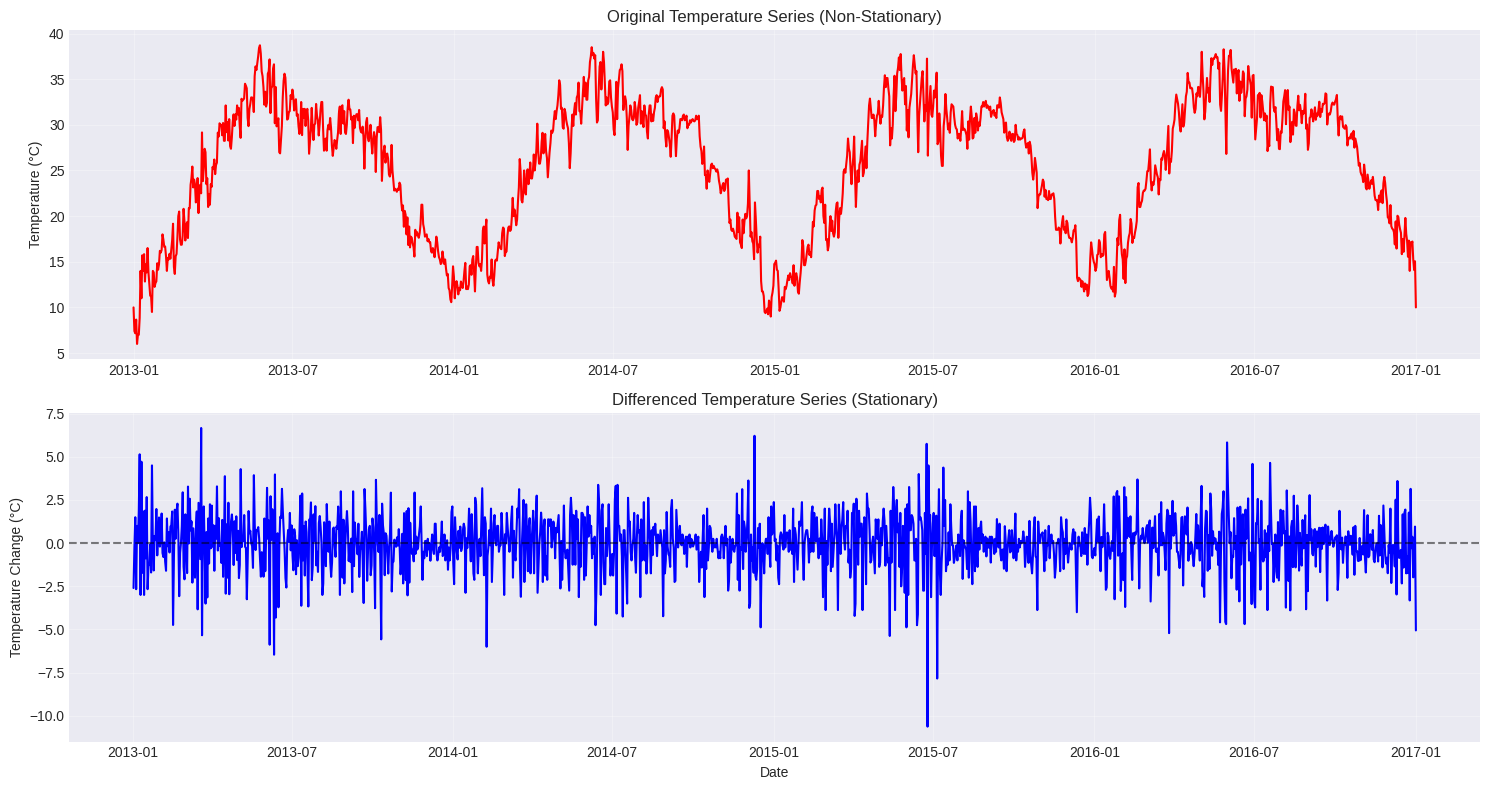


📊 DIFFERENCING EXPLANATION:
• Differencing removes trend and seasonality by looking at changes between days
• The differenced series now fluctuates around zero
• This stationary series can now be used for ARIMA modeling


In [48]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))

# Original series
ax1.plot(train.index, train['meantemp'], color='red')
ax1.set_title('Original Temperature Series (Non-Stationary)')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(True, alpha=0.3)

# Differenced series
ax2.plot(train.index, train['temp_diff_1'], color='blue')
ax2.set_title('Differenced Temperature Series (Stationary)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Temperature Change (°C)')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n📊 DIFFERENCING EXPLANATION:")
print("• Differencing removes trend and seasonality by looking at changes between days")
print("• The differenced series now fluctuates around zero")
print("• This stationary series can now be used for ARIMA modeling")

In [49]:
train['year'] = train.index.year
train['month'] = train.index.month
train['month_day'] = train.index.strftime('%m-%d')

In [52]:
pivot_temp = train.pivot_table(values='meantemp', index='month_day', columns='year', aggfunc='mean')

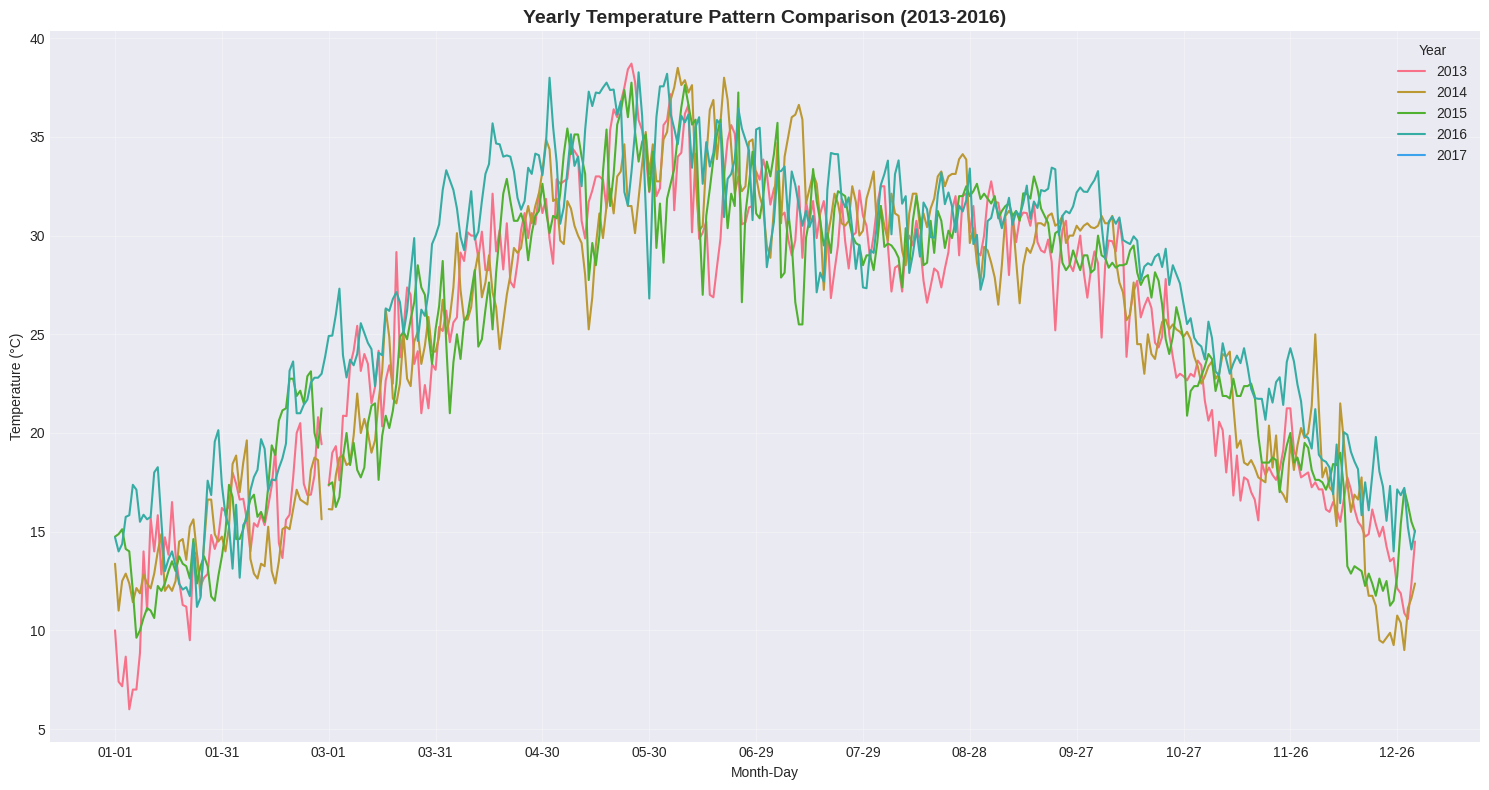


📊 YEARLY PATTERN INSIGHTS:
• Temperature patterns are consistent across years
• Peak temperatures occur around May-June (summer)
• Lowest temperatures occur around December-January (winter)
• Minor variations between years show natural climate variability


In [53]:
plt.figure(figsize=(15, 8))
for year in pivot_temp.columns:
    plt.plot(pivot_temp.index, pivot_temp[year], label=str(year), linewidth=1.5)

plt.title('Yearly Temperature Pattern Comparison (2013-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Month-Day')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.xticks(pivot_temp.index[::30])  # Show every 30th day label
plt.tight_layout()
plt.show()

print("\n📊 YEARLY PATTERN INSIGHTS:")
print("• Temperature patterns are consistent across years")
print("• Peak temperatures occur around May-June (summer)")
print("• Lowest temperatures occur around December-January (winter)")
print("• Minor variations between years show natural climate variability")